# Wikitext_2-BPE-Tokenizer

**Objective:** Build, train, evaluate, and save a Byte Pair Encoding (BPE) tokenizer from scratch using the WikiText-2 dataset from HuggingFace.

---

## Table of Contents
1. [Environment Setup](#1-setup)
2. [Load & Explore the Dataset](#2-load--explore-the-dataset)
3. [Data Cleaning & Preprocessing](#3-data-cleaning--preprocessing)
4. [BPE Tokenizer Training](#4-bpe-tokenizer-training)
5. [Tokenizer Evaluation](#5-tokenizer-evaluation)
6. [Save & Reload the Tokenizer](#6-save--reload-the-tokenizer)
7. [Summary & Conclusions](#7-summary--conclusions)


---
## 1. Setup

In [8]:
import re
import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from pathlib import Path
warnings.filterwarnings('ignore')

# HuggingFace
from datasets import load_dataset
from tokenizers import (
    Tokenizer,
    models,
    trainers,
    pre_tokenizers,
    decoders,
    processors,
    normalizers,
)
from tokenizers.normalizers import NFD, Lowercase, StripAccents, Replace, Strip, Sequence as NormSequence
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.processors import TemplateProcessing
from transformers import PreTrainedTokenizerFast

# Output directories
DATA_DIR = "Data"
os.makedirs(DATA_DIR, exist_ok=True)

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Constants
VOCAB_SIZE     = 30_000
SPECIAL_TOKENS = ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']
SAVE_DIR       = './custom_bpe_tokenizer'

print('All imports successful ✓')
print(f'Vocabulary size target : {VOCAB_SIZE:,}')
print(f'Special tokens         : {SPECIAL_TOKENS}')

All imports successful ✓
Vocabulary size target : 30,000
Special tokens         : ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']


---
## 2. Load & Explore the Dataset

Load the **WikiText-2-v1** subset (~44.8k rows) from HuggingFace and perform initial exploratory analysis.

In [2]:
# ─── 2.1  Load WikiText-2 ─────────────────────────────────────────────
print('Loading WikiText-2-v1 from HuggingFace...')
dataset = load_dataset('Salesforce/wikitext', 'wikitext-2-v1')
print(dataset)

print('\nSplit sizes:')
for split, ds in dataset.items():
    print(f'  {split:10s}: {len(ds):>6,} rows')

print('\nSample rows from training set:')
for i, row in enumerate(dataset['train'].select(range(5))):
    print(f'  [{i}] {repr(row["text"][:120])}')

Loading WikiText-2-v1 from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

wikitext-2-v1/test-00000-of-00001.parque(…):   0%|          | 0.00/685k [00:00<?, ?B/s]

wikitext-2-v1/train-00000-of-00001.parqu(…):   0%|          | 0.00/6.07M [00:00<?, ?B/s]

wikitext-2-v1/validation-00000-of-00001.(…):   0%|          | 0.00/618k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

Split sizes:
  test      :  4,358 rows
  train     : 36,718 rows
  validation:  3,760 rows

Sample rows from training set:
  [0] ''
  [1] ' = Valkyria Chronicles III = \n'
  [2] ''
  [3] ' Senjō no Valkyria 3 : <unk> Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly refe'
  [4] ' The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While i'


In [3]:
# ─── 2.2  Dataset Statistics ──────────────────────────────────────────────
def compute_stats(texts):
    """Compute basic corpus statistics."""
    lengths_chars = [len(t) for t in texts if t.strip()]
    lengths_words = [len(t.split()) for t in texts if t.strip()]
    return {
        'total_rows'    : len(texts),
        'non_empty_rows': len(lengths_chars),
        'total_chars'   : sum(lengths_chars),
        'total_words'   : sum(lengths_words),
        'avg_chars'     : np.mean(lengths_chars),
        'avg_words'     : np.mean(lengths_words),
        'median_words'  : np.median(lengths_words),
        'max_words'     : max(lengths_words),
    }

train_texts = dataset['train']['text']
val_texts   = dataset['validation']['text']
test_texts  = dataset['test']['text']

stats = {split: compute_stats(dataset[split]['text']) for split in ['train', 'validation', 'test']}
stats_df = pd.DataFrame(stats).T
print('Dataset Statistics:')
print(stats_df.to_string())

Dataset Statistics:
            total_rows  non_empty_rows  total_chars  total_words   avg_chars  avg_words  median_words  max_words
train          36718.0         23767.0   10754535.0    2051910.0  452.498633  86.334413          74.0      699.0
validation      3760.0          2461.0    1117594.0     213886.0  454.121902  86.910199          75.0      429.0
test            4358.0          2891.0    1252084.0     241211.0  433.097198  83.435144          67.0      481.0


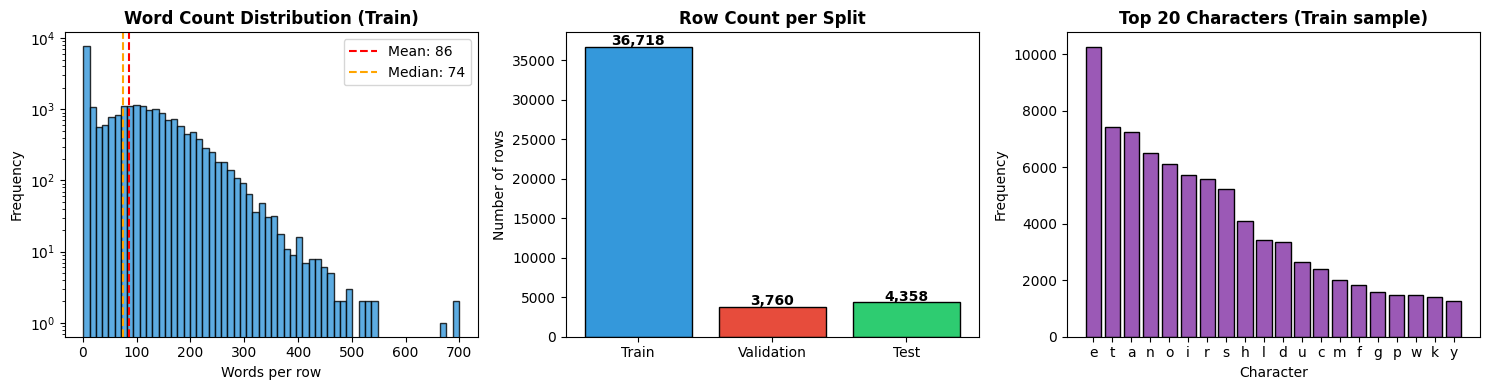

In [10]:
# ─── 2.3  Visualize Text Length Distribution ─────────────────────────────
train_word_lengths = [len(t.split()) for t in train_texts if t.strip()]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train_word_lengths, bins=60, color='#3498DB', edgecolor='black', alpha=0.8)
axes[0].axvline(np.mean(train_word_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(train_word_lengths):.0f}')
axes[0].axvline(np.median(train_word_lengths), color='orange', linestyle='--', label=f'Median: {np.median(train_word_lengths):.0f}')
axes[0].set_title('Word Count Distribution (Train)', fontweight='bold')
axes[0].set_xlabel('Words per row'); axes[0].set_ylabel('Frequency')
axes[0].legend(); axes[0].set_yscale('log')

split_names  = ['Train', 'Validation', 'Test']
split_rows   = [len(dataset[s]) for s in ['train', 'validation', 'test']]
split_colors = ['#3498DB', '#E74C3C', '#2ECC71']
bars = axes[1].bar(split_names, split_rows, color=split_colors, edgecolor='black')
for bar, val in zip(bars, split_rows):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'{val:,}', ha='center', fontweight='bold')
axes[1].set_title('Row Count per Split', fontweight='bold')
axes[1].set_ylabel('Number of rows')

sample_text = ' '.join(train_texts[:500])
char_freq = Counter(c for c in sample_text if c.isalpha())
top_chars = dict(char_freq.most_common(20))
axes[2].bar(top_chars.keys(), top_chars.values(), color='#9B59B6', edgecolor='black')
axes[2].set_title('Top 20 Characters (Train sample)', fontweight='bold')
axes[2].set_xlabel('Character'); axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/dataset_exploration.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Data Cleaning & Preprocessing

Steps:
- Remove empty / whitespace-only lines
- Remove special corpus tokens (e.g., `<unk>`, `= Heading =`)
- Normalize whitespace
- **Deduplicate** exact duplicate sentences

In [11]:
# ─── 3.1  Cleaning Functions ──────────────────────────────────────────────
def clean_text(text: str) -> str:
    """
    Clean a single text string:
    - Remove WikiText special tokens: <unk>, = Headers =
    - Normalize @-@ to hyphen
    - Normalize multiple whitespace to single space
    - Strip leading/trailing whitespace
    """
    text = re.sub(r'<\s*unk\s*>', '', text)                        # remove <unk>
    text = re.sub(r'^\s*=+\s+.*?\s+=+\s*$', '', text, flags=re.MULTILINE)  # remove headers
    text = re.sub(r'@\s*[-–]\s*@', '-', text)                      # @-@ -> hyphen
    text = re.sub(r'[ \t]+', ' ', text)                             # normalize spaces
    return text.strip()


def preprocess_corpus(texts: list) -> list:
    """
    Apply cleaning and deduplication to a list of text strings.
    Returns cleaned, deduplicated, non-empty strings.
    """
    print(f'  Raw rows              : {len(texts):,}')
    cleaned = [clean_text(t) for t in texts]
    cleaned = [t for t in cleaned if len(t.split()) >= 3]
    print(f'  After removing empties: {len(cleaned):,}')
    seen, deduped = set(), []
    for t in cleaned:
        if t not in seen:
            seen.add(t)
            deduped.append(t)
    print(f'  After deduplication   : {len(deduped):,}  (removed {len(cleaned)-len(deduped):,} duplicates)')
    return deduped


print('Preprocessing training set...')
clean_train = preprocess_corpus(train_texts)

print('\nPreprocessing validation set...')
clean_val = preprocess_corpus(val_texts)

print('\nPreprocessing test set...')
clean_test = preprocess_corpus(test_texts)

Preprocessing training set...
  Raw rows              : 36,718
  After removing empties: 17,242
  After deduplication   : 17,168  (removed 74 duplicates)

Preprocessing validation set...
  Raw rows              : 3,760
  After removing empties: 1,817
  After deduplication   : 1,815  (removed 2 duplicates)

Preprocessing test set...
  Raw rows              : 4,358
  After removing empties: 2,072
  After deduplication   : 2,066  (removed 6 duplicates)


In [12]:
# ─── 3.2  Inspect Cleaned Text ──────────────────────────────────────────────
print('Sample cleaned training sentences:')
for i, sent in enumerate(clean_train[:5]):
    print(f'  [{i}] {sent[:130]}')

print(f'\nTotal characters in training corpus: {sum(len(t) for t in clean_train):,}')
print(f'Total words in training corpus     : {sum(len(t.split()) for t in clean_train):,}')

Sample cleaned training sentences:
  [0] Senjō no Valkyria 3 : Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyr
  [1] The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained 
  [2] It met with positive sales in Japan , and was praised by both Japanese and western critics . After release , it received downloada
  [3] As with previous Chronicles games , Valkyria Chronicles III is a tactical role - playing game where players take control of a mili
  [4] The game 's battle system , the system , is carried over directly from Chronicles . During missions , players select each unit usi

Total characters in training corpus: 10,166,507
Total words in training corpus     : 1,952,276


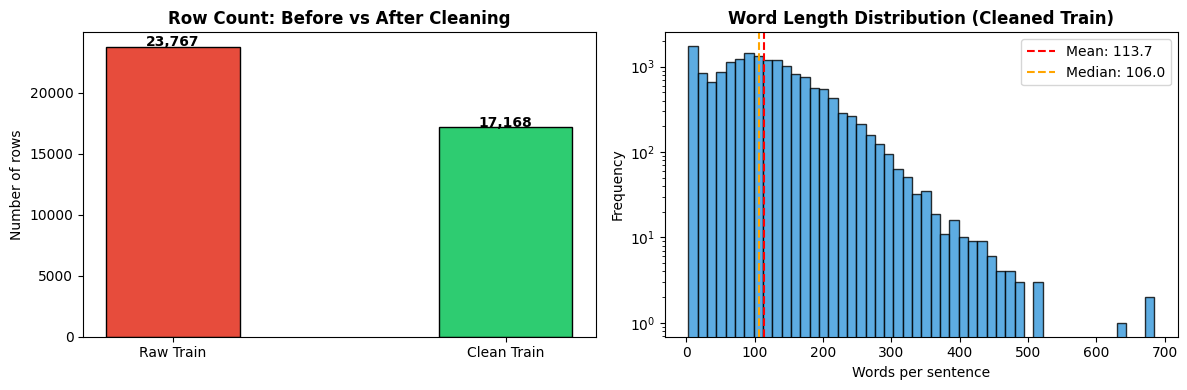

In [14]:
# ─── 3.3  Before vs After Cleaning Comparison ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = ['Raw Train', 'Clean Train']
counts = [len([t for t in train_texts if t.strip()]), len(clean_train)]
colors = ['#E74C3C', '#2ECC71']
bars = axes[0].bar(labels, counts, color=colors, edgecolor='black', width=0.4)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Row Count: Before vs After Cleaning', fontweight='bold')
axes[0].set_ylabel('Number of rows')

clean_lengths = [len(t.split()) for t in clean_train]
axes[1].hist(clean_lengths, bins=50, color='#3498DB', edgecolor='black', alpha=0.8)
axes[1].axvline(np.mean(clean_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(clean_lengths):.1f}')
axes[1].axvline(np.median(clean_lengths), color='orange', linestyle='--', label=f'Median: {np.median(clean_lengths):.1f}')
axes[1].set_title('Word Length Distribution (Cleaned Train)', fontweight='bold')
axes[1].set_xlabel('Words per sentence'); axes[1].set_ylabel('Frequency')
axes[1].set_yscale('log'); axes[1].legend()

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/cleaning_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 4. BPE Tokenizer Training

We use HuggingFace's `tokenizers` library to build a **BPE tokenizer from scratch**:
- **Model**: BPE (Byte Pair Encoding)
- **Normalizer**: NFD → Lowercase → StripAccents → Strip
- **Pre-tokenizer**: Whitespace
- **Decoder**: BPE Decoder
- **Post-processor**: Adds `[CLS]` and `[SEP]` tokens automatically
- **Vocabulary size**: 30,000
- **Special tokens**: `[PAD]`, `[UNK]`, `[CLS]`, `[SEP]`, `[MASK]`

In [15]:
# ─── 4.1  Initialize BPE Tokenizer ───────────────────────────────────────────
bpe_tokenizer = Tokenizer(models.BPE(unk_token='[UNK]'))

bpe_tokenizer.normalizer = NormSequence([
    NFD(),
    Lowercase(),
    StripAccents(),
    Replace(r'\s+', ' '),
    Strip(),
])

bpe_tokenizer.pre_tokenizer = Whitespace()
bpe_tokenizer.decoder = decoders.BPEDecoder()

print('BPE Tokenizer initialized ✓')
print(f'  Model         : {type(bpe_tokenizer.model).__name__}')
print(f'  Normalizer    : NFD → Lowercase → StripAccents → Strip')
print(f'  Pre-tokenizer : Whitespace')
print(f'  Decoder       : BPEDecoder')

BPE Tokenizer initialized ✓
  Model         : BPE
  Normalizer    : NFD → Lowercase → StripAccents → Strip
  Pre-tokenizer : Whitespace
  Decoder       : BPEDecoder


In [17]:
# ─── 4.2  Configure BPE Trainer ──────────────────────────────────────────────
trainer = trainers.BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=SPECIAL_TOKENS,
    min_frequency=2,
    show_progress=True,
    continuing_subword_prefix='##',
)

print('BPE Trainer Configuration:')
print(f'  Vocabulary size          : {VOCAB_SIZE:,}')
print(f'  Special tokens           : {SPECIAL_TOKENS}')
print(f'  Min token frequency      : 2')
print(f'  Continuing subword prefix: ##')

BPE Trainer Configuration:
  Vocabulary size          : 30,000
  Special tokens           : ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']
  Min token frequency      : 2
  Continuing subword prefix: ##


In [18]:
# ─── 4.3  Train the Tokenizer ──────────────────────────────────────────────
def get_training_corpus(texts, batch_size=1000):
    """Yield batches of text for memory-efficient tokenizer training."""
    for i in range(0, len(texts), batch_size):
        yield texts[i : i + batch_size]

print(f'Training BPE tokenizer on {len(clean_train):,} sentences...')
print('This may take 1–3 minutes depending on your hardware.\n')

bpe_tokenizer.train_from_iterator(
    get_training_corpus(clean_train),
    trainer=trainer,
    length=len(clean_train),
)

actual_vocab_size = bpe_tokenizer.get_vocab_size()
print(f'\nTraining complete! ✓')
print(f'  Actual vocabulary size: {actual_vocab_size:,}')

Training BPE tokenizer on 17,168 sentences...
This may take 1–3 minutes depending on your hardware.


Training complete! ✓
  Actual vocabulary size: 30,000


In [19]:
# ─── 4.4  Add Post-Processor ([CLS] and [SEP]) ────────────────────────────
cls_id = bpe_tokenizer.token_to_id('[CLS]')
sep_id = bpe_tokenizer.token_to_id('[SEP]')
pad_id = bpe_tokenizer.token_to_id('[PAD]')

print('Special token IDs:')
for tok in SPECIAL_TOKENS:
    print(f'  {tok:8s} -> {bpe_tokenizer.token_to_id(tok)}')

bpe_tokenizer.post_processor = TemplateProcessing(
    single='[CLS] $A [SEP]',
    pair='[CLS] $A [SEP] $B:1 [SEP]:1',
    special_tokens=[('[CLS]', cls_id), ('[SEP]', sep_id)],
)
bpe_tokenizer.enable_padding(pad_id=pad_id, pad_token='[PAD]')

print('\nPost-processor configured: [CLS] ... [SEP]  ✓')
print('Padding enabled with [PAD] token ✓')

Special token IDs:
  [PAD]    -> 0
  [UNK]    -> 1
  [CLS]    -> 2
  [SEP]    -> 3
  [MASK]   -> 4

Post-processor configured: [CLS] ... [SEP]  ✓
Padding enabled with [PAD] token ✓


In [20]:
# ─── 4.5  Quick Sanity Check ─────────────────────────────────────────────────
test_sentences = [
    'The quick brown fox jumps over the lazy dog.',
    'Tokenization is a fundamental step in natural language processing.',
    'WikiText is a benchmark dataset for language modeling tasks.',
    'Byte Pair Encoding merges the most frequent character pairs iteratively.',
]

print('Tokenization Sanity Check:\n')
for sent in test_sentences:
    enc = bpe_tokenizer.encode(sent)
    print(f'  Input   : {sent}')
    print(f'  Tokens  : {enc.tokens}')
    print(f'  IDs     : {enc.ids}')
    print(f'  Decoded : {bpe_tokenizer.decode(enc.ids)}')
    print()

Tokenization Sanity Check:

  Input   : The quick brown fox jumps over the lazy dog.
  Tokens  : ['[CLS]', 'the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'la', '##zy', 'dog', '.', '[SEP]']
  IDs     : [2, 269, 2471, 1898, 2982, 11709, 560, 269, 792, 3197, 4224, 18, 3]
  Decoded : thequickbrownfoxjumpsoverthela##zydog.

  Input   : Tokenization is a fundamental step in natural language processing.
  Tokens  : ['[CLS]', 'to', '##ken', '##ization', 'is', 'a', 'fundamental', 'step', 'in', 'natural', 'language', 'processing', '.', '[SEP]']
  IDs     : [2, 289, 3178, 2263, 331, 42, 8366, 4141, 279, 2820, 2724, 10301, 18, 3]
  Decoded : to##ken##izationisafundamentalstepinnaturallanguageprocessing.

  Input   : WikiText is a benchmark dataset for language modeling tasks.
  Tokens  : ['[CLS]', 'wik', '##ite', '##xt', 'is', 'a', 'bench', '##mark', 'dat', '##as', '##et', 'for', 'language', 'modeling', 'tasks', '.', '[SEP]']
  IDs     : [2, 9150, 580, 1126, 331, 42, 17349, 6280, 9544, 28

In [21]:
# ─── 4.6  Vocabulary Inspection ──────────────────────────────────────────────
vocab = bpe_tokenizer.get_vocab()
special    = [t for t in vocab if t in SPECIAL_TOKENS]
single_chars = [t for t in vocab if len(t) == 1 and t.isalpha()]
subwords   = [t for t in vocab if t.startswith('##')]
full_words = [t for t in vocab if not t.startswith('##') and t not in SPECIAL_TOKENS and len(t) > 1]

print('Vocabulary Breakdown:')
print(f'  Total vocabulary size : {len(vocab):,}')
print(f'  Special tokens        : {len(special)}')
print(f'  Single characters     : {len(single_chars)}')
print(f'  Subword tokens (##)   : {len(subwords):,}')
print(f'  Full word tokens      : {len(full_words):,}')
print(f'\n  Sample subwords  : {sorted(subwords, key=len)[:20]}')
print(f'  Sample full words: {sorted(full_words, key=lambda x: vocab[x])[:20]}')

Vocabulary Breakdown:
  Total vocabulary size : 30,000
  Special tokens        : 5
  Single characters     : 100
  Subword tokens (##)   : 5,128
  Full word tokens      : 24,687

  Sample subwords  : ['##k', '##ย', '##-', '##ル', '##リ', '##y', '##า', '##z', '##ッ', '##6', '##ร', '##n', '##v', '##3', '##ص', '##2', '##p', '##ณ', '##l', '##q']
  Sample full words: ['th', 'the', 'in', 'of', 'and', 'to', 'on', 'was', 'st', 'for', 'wh', 'as', 're', 'be', 'al', 'with', 'that', 'it', 'is', 'by']


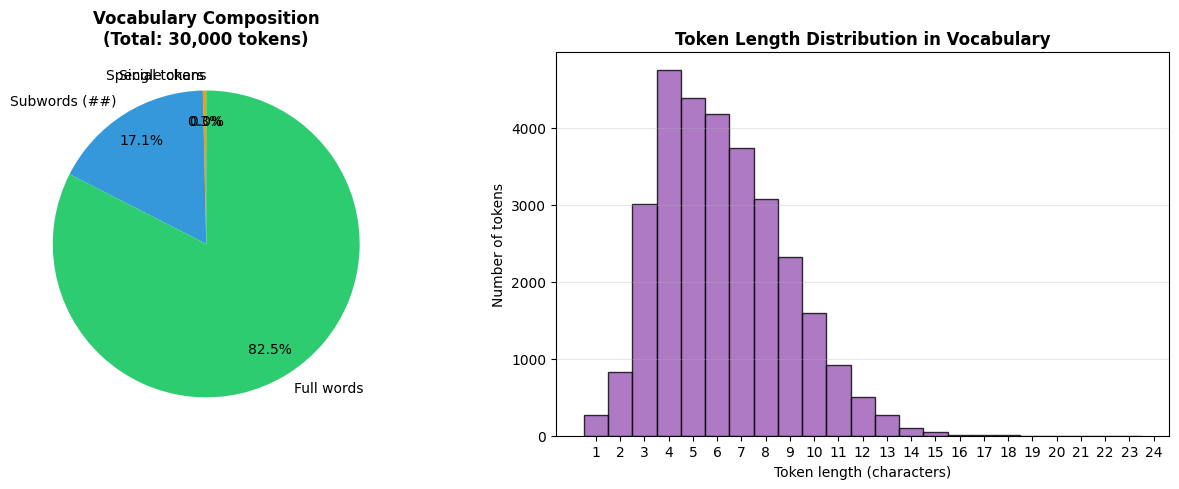

In [23]:
# ─── 4.7  Vocabulary Composition Plot ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sizes  = [len(special), len(single_chars), len(subwords), len(full_words)]
labels = ['Special tokens', 'Single chars', 'Subwords (##)', 'Full words']
colors = ['#E74C3C', '#F39C12', '#3498DB', '#2ECC71']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, pctdistance=0.8)
axes[0].set_title(f'Vocabulary Composition\n(Total: {len(vocab):,} tokens)', fontweight='bold')

all_tokens = list(vocab.keys())
tok_lengths = [len(t.replace('##', '')) for t in all_tokens if t not in SPECIAL_TOKENS]
axes[1].hist(tok_lengths, bins=range(1, 25), color='#9B59B6', edgecolor='black', alpha=0.8, align='left')
axes[1].set_title('Token Length Distribution in Vocabulary', fontweight='bold')
axes[1].set_xlabel('Token length (characters)'); axes[1].set_ylabel('Number of tokens')
axes[1].set_xticks(range(1, 25)); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/vocab_composition.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Tokenizer Evaluation

Evaluate on the validation and test splits. Metrics reported:
- **Vocabulary size**
- **Tokenization consistency** (same input → same output)
- **Average tokens per sentence**
- **Compression ratio** (characters per token)
- **Unknown token rate**
- **UNK-free coverage** (% sentences with no UNK)

In [24]:
# ─── 5.1  Evaluation Function ──────────────────────────────────────────────
def evaluate_tokenizer(tokenizer, texts, split_name=''):
    """Evaluate a tokenizer on a list of texts. Returns metrics dict."""
    unk_id      = tokenizer.token_to_id('[UNK]')
    special_ids = {
        tokenizer.token_to_id('[CLS]'),
        tokenizer.token_to_id('[SEP]'),
        tokenizer.token_to_id('[PAD]'),
        tokenizer.token_to_id('[MASK]'),
    }
    tokens_per_sentence, chars_per_sentence, unk_counts = [], [], []
    no_unk_count = 0

    encodings = tokenizer.encode_batch(texts)
    for text, enc in zip(texts, encodings):
        content_ids = [i for i in enc.ids if i not in special_ids]
        n_unk = content_ids.count(unk_id)
        tokens_per_sentence.append(len(content_ids))
        chars_per_sentence.append(len(text))
        unk_counts.append(n_unk)
        if n_unk == 0:
            no_unk_count += 1

    # Consistency: same input twice -> same output
    sample = texts[:100]
    consistency_ok = all(a.ids == b.ids for a, b in zip(
        tokenizer.encode_batch(sample), tokenizer.encode_batch(sample)))

    total_tokens = sum(tokens_per_sentence)
    total_chars  = sum(chars_per_sentence)
    return {
        'split'                  : split_name,
        'sentences'              : len(texts),
        'avg_tokens_per_sentence': round(np.mean(tokens_per_sentence), 2),
        'median_tokens'          : round(np.median(tokens_per_sentence), 2),
        'total_tokens'           : total_tokens,
        'total_chars'            : total_chars,
        'compression_ratio'      : round(total_chars / max(total_tokens, 1), 4),
        'avg_unk_per_sentence'   : round(np.mean(unk_counts), 4),
        'unk_free_coverage_%'    : round(100 * no_unk_count / max(len(texts), 1), 2),
        'consistency'            : consistency_ok,
        'vocabulary_size'        : tokenizer.get_vocab_size(),
    }, tokens_per_sentence


print('Evaluating tokenizer on validation set...')
val_metrics, val_tok_lens = evaluate_tokenizer(bpe_tokenizer, clean_val, 'validation')

print('Evaluating tokenizer on test set...')
test_metrics, test_tok_lens = evaluate_tokenizer(bpe_tokenizer, clean_test, 'test')

print('Done ✓')

Evaluating tokenizer on validation set...
Evaluating tokenizer on test set...
Done ✓


In [25]:
# ─── 5.2  Print Evaluation Results ───────────────────────────────────────────
results_df = pd.DataFrame([val_metrics, test_metrics]).set_index('split')

print('\n' + '='*65)
print('  TOKENIZER EVALUATION RESULTS')
print('='*65)
print(results_df.T.to_string())
print('='*65)

print('\nMetric Explanations:')
print('  avg_tokens_per_sentence : Mean BPE tokens per sentence (excl. special tokens)')
print('  compression_ratio       : Avg chars per token — higher = more compression')
print('  unk_free_coverage_%     : % sentences with zero UNK tokens — higher is better')
print('  consistency             : Same input always produces identical token output')


  TOKENIZER EVALUATION RESULTS
split                   validation     test
sentences                     1815     2066
avg_tokens_per_sentence     111.66   109.12
median_tokens                106.0     98.0
total_tokens                202670   225449
total_chars                1021495  1130424
compression_ratio           5.0402   5.0141
avg_unk_per_sentence           0.0      0.0
unk_free_coverage_%          100.0    100.0
consistency                   True     True
vocabulary_size              30000    30000

Metric Explanations:
  avg_tokens_per_sentence : Mean BPE tokens per sentence (excl. special tokens)
  compression_ratio       : Avg chars per token — higher = more compression
  unk_free_coverage_%     : % sentences with zero UNK tokens — higher is better
  consistency             : Same input always produces identical token output


In [26]:
# ─── 5.3  Evaluate on Training Sample ────────────────────────────────────────
train_sample = random.sample(clean_train, min(5000, len(clean_train)))

print('Evaluating on training sample (5,000 sentences)...')
train_metrics, train_tok_lens = evaluate_tokenizer(bpe_tokenizer, train_sample, 'train (sample)')

all_results = pd.DataFrame([train_metrics, val_metrics, test_metrics]).set_index('split')
print('\nAll splits comparison:')
print(all_results[['sentences', 'avg_tokens_per_sentence', 'compression_ratio',
                    'unk_free_coverage_%', 'consistency']].to_string())

Evaluating on training sample (5,000 sentences)...

All splits comparison:
                sentences  avg_tokens_per_sentence  compression_ratio  unk_free_coverage_%  consistency
split                                                                                                  
train (sample)       5000                   116.34             5.0655                100.0         True
validation           1815                   111.66             5.0402                100.0         True
test                 2066                   109.12             5.0141                100.0         True


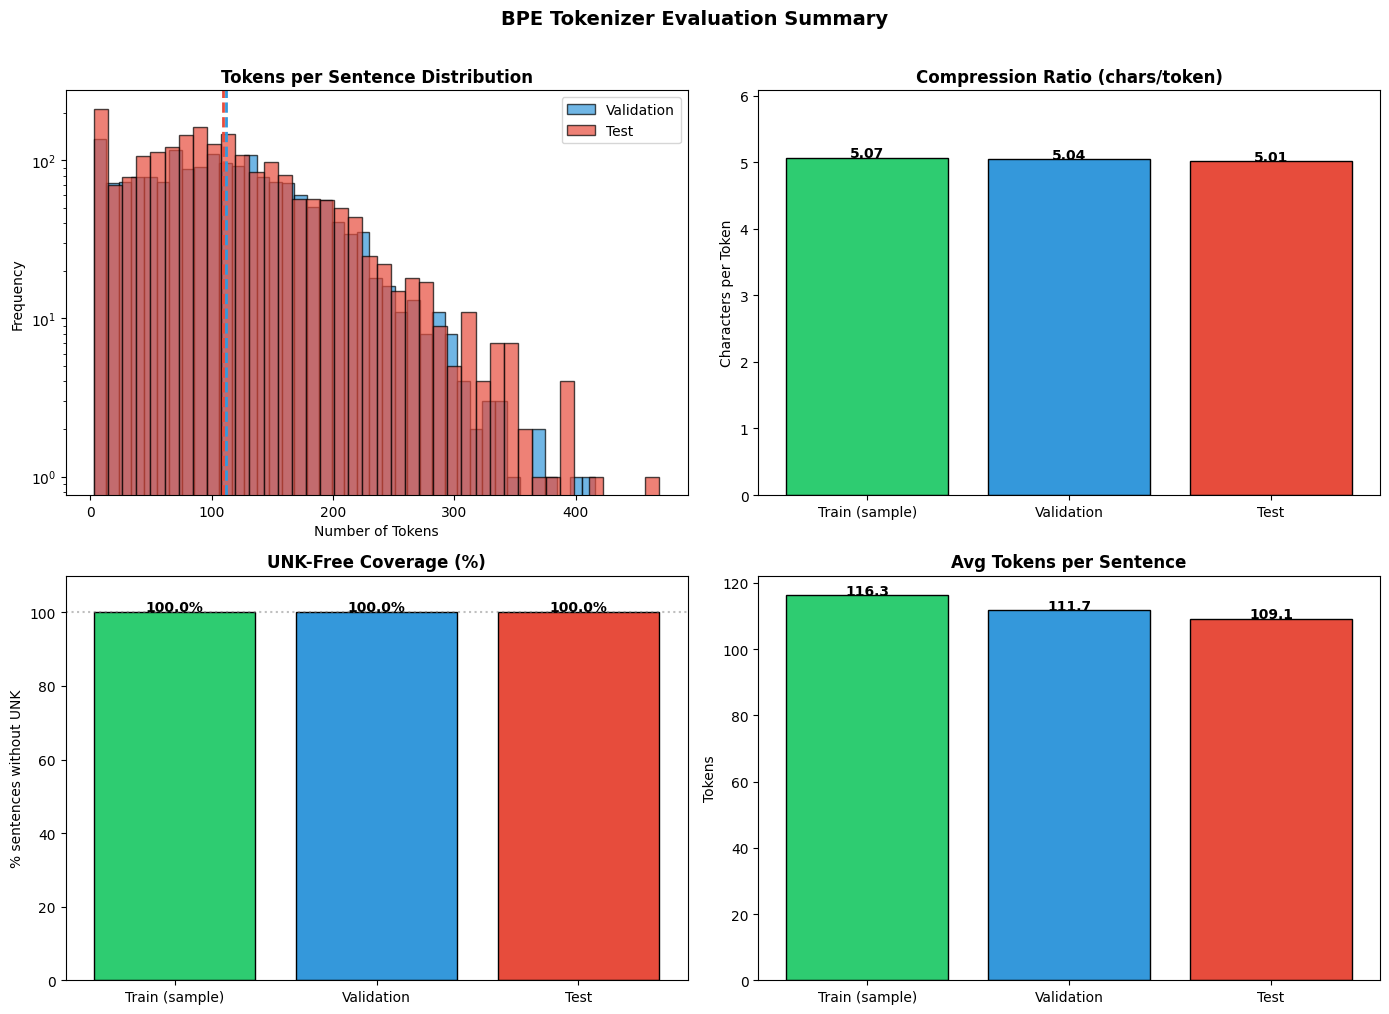

In [28]:
# ─── 5.4  Evaluation Plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (A) Token distribution: val vs test
axes[0,0].hist(val_tok_lens,  bins=40, alpha=0.7, color='#3498DB', label='Validation', edgecolor='black')
axes[0,0].hist(test_tok_lens, bins=40, alpha=0.7, color='#E74C3C', label='Test',       edgecolor='black')
axes[0,0].axvline(np.mean(val_tok_lens),  color='#3498DB', linestyle='--', linewidth=2)
axes[0,0].axvline(np.mean(test_tok_lens), color='#E74C3C', linestyle='--', linewidth=2)
axes[0,0].set_title('Tokens per Sentence Distribution', fontweight='bold')
axes[0,0].set_xlabel('Number of Tokens'); axes[0,0].set_ylabel('Frequency')
axes[0,0].legend(); axes[0,0].set_yscale('log')

# (B) Compression ratio
splits = ['Train (sample)', 'Validation', 'Test']
comp_ratios = [train_metrics['compression_ratio'], val_metrics['compression_ratio'], test_metrics['compression_ratio']]
bars = axes[0,1].bar(splits, comp_ratios, color=['#2ECC71','#3498DB','#E74C3C'], edgecolor='black')
for bar, v in zip(bars, comp_ratios):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{v:.2f}', ha='center', fontweight='bold')
axes[0,1].set_title('Compression Ratio (chars/token)', fontweight='bold')
axes[0,1].set_ylabel('Characters per Token')
axes[0,1].set_ylim(0, max(comp_ratios)*1.2)

# (C) UNK-free coverage
coverages = [train_metrics['unk_free_coverage_%'], val_metrics['unk_free_coverage_%'], test_metrics['unk_free_coverage_%']]
bars2 = axes[1,0].bar(splits, coverages, color=['#2ECC71','#3498DB','#E74C3C'], edgecolor='black')
for bar, v in zip(bars2, coverages):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1,0].set_title('UNK-Free Coverage (%)', fontweight='bold')
axes[1,0].set_ylabel('% sentences without UNK')
axes[1,0].set_ylim(0, 110)
axes[1,0].axhline(100, color='gray', linestyle=':', alpha=0.5)

# (D) Avg tokens per sentence
avg_toks = [train_metrics['avg_tokens_per_sentence'], val_metrics['avg_tokens_per_sentence'], test_metrics['avg_tokens_per_sentence']]
bars3 = axes[1,1].bar(splits, avg_toks, color=['#2ECC71','#3498DB','#E74C3C'], edgecolor='black')
for bar, v in zip(bars3, avg_toks):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{v:.1f}', ha='center', fontweight='bold')
axes[1,1].set_title('Avg Tokens per Sentence', fontweight='bold')
axes[1,1].set_ylabel('Tokens')

plt.suptitle('BPE Tokenizer Evaluation Summary', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/tokenizer_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Save & Reload the Tokenizer

Save the trained tokenizer in HuggingFace-compatible format using `PreTrainedTokenizerFast`, then demonstrate reloading and using it for encoding/decoding.

In [29]:
# ─── 6.1  Wrap as PreTrainedTokenizerFast ─────────────────────────────────
hf_tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=bpe_tokenizer,
    unk_token='[UNK]',
    pad_token='[PAD]',
    cls_token='[CLS]',
    sep_token='[SEP]',
    mask_token='[MASK]',
)

print('PreTrainedTokenizerFast created ✓')
print(f'  Vocab size  : {hf_tokenizer.vocab_size:,}')
print(f'  PAD token   : {hf_tokenizer.pad_token} (id={hf_tokenizer.pad_token_id})')
print(f'  UNK token   : {hf_tokenizer.unk_token} (id={hf_tokenizer.unk_token_id})')
print(f'  CLS token   : {hf_tokenizer.cls_token} (id={hf_tokenizer.cls_token_id})')
print(f'  SEP token   : {hf_tokenizer.sep_token} (id={hf_tokenizer.sep_token_id})')
print(f'  MASK token  : {hf_tokenizer.mask_token} (id={hf_tokenizer.mask_token_id})')

PreTrainedTokenizerFast created ✓
  Vocab size  : 30,000
  PAD token   : [PAD] (id=0)
  UNK token   : [UNK] (id=1)
  CLS token   : [CLS] (id=2)
  SEP token   : [SEP] (id=3)
  MASK token  : [MASK] (id=4)


In [30]:
# ─── 6.2  Save the Tokenizer ─────────────────────────────────────────────────
import os
os.makedirs(SAVE_DIR, exist_ok=True)
hf_tokenizer.save_pretrained(SAVE_DIR)

print(f'Tokenizer saved to: {SAVE_DIR}/')
print('\nSaved files:')
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(os.path.join(SAVE_DIR, f))
    print(f'  {f:35s}  {size:>8,} bytes')

Tokenizer saved to: ./custom_bpe_tokenizer/

Saved files:
  tokenizer.json                       2,144,610 bytes
  tokenizer_config.json                     368 bytes


In [31]:
# ─── 6.3  Reload the Tokenizer ──────────────────────────────────────────────
reloaded_tokenizer = PreTrainedTokenizerFast.from_pretrained(SAVE_DIR)

print(f'Tokenizer reloaded from: {SAVE_DIR}/ ✓')
print(f'  Vocab size: {reloaded_tokenizer.vocab_size:,}')

# Verify reloaded tokenizer produces identical output
sample = 'The history of natural language processing generally started in the 1950s.'
orig_enc     = hf_tokenizer(sample)
reloaded_enc = reloaded_tokenizer(sample)

assert orig_enc['input_ids'] == reloaded_enc['input_ids'], 'Mismatch after reload!'
print('Reload verification: PASSED ✓  (original == reloaded)')

Tokenizer reloaded from: ./custom_bpe_tokenizer/ ✓
  Vocab size: 30,000
Reload verification: PASSED ✓  (original == reloaded)


In [32]:
# ─── 6.4  Encode / Decode Demo ──────────────────────────────────────────────
demo_texts = [
    'The quick brown fox jumps over the lazy dog.',
    'Natural language processing enables computers to understand human text.',
    'WikiText-2 is a small but clean English language modeling benchmark.',
]

print('Encode / Decode Demo with reloaded tokenizer:\n')
for text in demo_texts:
    enc = reloaded_tokenizer(text, return_tensors=None)
    tokens = reloaded_tokenizer.convert_ids_to_tokens(enc['input_ids'])
    decoded = reloaded_tokenizer.decode(enc['input_ids'], skip_special_tokens=True)
    print(f'  Input   : {text}')
    print(f'  Tokens  : {tokens}')
    print(f'  IDs     : {enc["input_ids"]}')
    print(f'  Decoded : {decoded}')
    print()

# Batch encoding with padding
print('Batch encoding with padding:')
batch = reloaded_tokenizer(demo_texts, padding=True, truncation=True, max_length=64, return_tensors=None)
for i, ids in enumerate(batch['input_ids']):
    print(f'  [{i}] length={len(ids)}  ids={ids[:10]}...')

Encode / Decode Demo with reloaded tokenizer:

  Input   : The quick brown fox jumps over the lazy dog.
  Tokens  : ['[CLS]', 'the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'la', '##zy', 'dog', '.', '[SEP]']
  IDs     : [2, 269, 2471, 1898, 2982, 11709, 560, 269, 792, 3197, 4224, 18, 3]
  Decoded : thequickbrownfoxjumpsoverthela##zydog.

  Input   : Natural language processing enables computers to understand human text.
  Tokens  : ['[CLS]', 'natural', 'language', 'processing', 'enables', 'computers', 'to', 'understand', 'human', 'text', '.', '[SEP]']
  IDs     : [2, 2820, 2724, 10301, 20396, 10087, 289, 6655, 1718, 3661, 18, 3]
  Decoded : naturallanguageprocessingenablescomputerstounderstandhumantext.

  Input   : WikiText-2 is a small but clean English language modeling benchmark.
  Tokens  : ['[CLS]', 'wik', '##ite', '##xt', '-', '2', 'is', 'a', 'small', 'but', 'clean', 'english', 'language', 'modeling', 'bench', '##mark', '.', '[SEP]']
  IDs     : [2, 9150, 580, 1126, 17,

In [34]:
# ─── 6.5  Pair Encoding Demo (sentence-pair tasks) ────────────────────────
sent_a = 'BPE tokenization splits words into subword units.'
sent_b = 'This helps handle out-of-vocabulary words gracefully.'

pair_enc = reloaded_tokenizer(sent_a, sent_b)
pair_tokens = reloaded_tokenizer.convert_ids_to_tokens(pair_enc['input_ids'])

print('Sentence-pair encoding:')
print(f'  Sentence A : {sent_a}')
print(f'  Sentence B : {sent_b}')
print(f'  Tokens     : {pair_tokens}')
print(f'  Token IDs  : {pair_enc["input_ids"]}')
token_type_ids = pair_enc.get('token_type_ids', 'N/A (not returned by this tokenizer)')
print(f'  Token types: {token_type_ids}')

Sentence-pair encoding:
  Sentence A : BPE tokenization splits words into subword units.
  Sentence B : This helps handle out-of-vocabulary words gracefully.
  Tokens     : ['[CLS]', 'b', '##pe', 'to', '##ken', '##ization', 'splits', 'words', 'into', 'sub', '##w', '##ord', 'units', '.', '[SEP]', 'this', 'helps', 'handle', 'out', '-', 'of', '-', 'voc', '##abulary', 'words', 'grace', '##fully', '.', '[SEP]']
  Token IDs  : [2, 43, 8632, 289, 3178, 2263, 16448, 3878, 596, 766, 214, 435, 2525, 18, 3, 447, 9076, 10866, 571, 17, 281, 17, 2080, 25086, 3878, 6514, 7900, 18, 3]
  Token types: N/A (not returned by this tokenizer)


---
## 7. Summary & Conclusions

This notebook demonstrated the full lifecycle of building a custom BPE tokenizer:

| Step | Description |
|---|---|
| Data Loading | WikiText-2-v1 from HuggingFace (~44.8k rows) |
| Cleaning | Removed `<unk>`, headers, normalized whitespace |
| Deduplication | Exact-match dedup on training split |
| Tokenizer | BPE with NFD→Lowercase→StripAccents normalizer |
| Vocabulary | 30,000 tokens with `##` subword prefix |
| Special tokens | `[PAD]`, `[UNK]`, `[CLS]`, `[SEP]`, `[MASK]` |
| Post-processor | Auto `[CLS]...[SEP]` wrapping |
| Evaluation | Compression ratio, UNK-free coverage, consistency |
| Saved format | HuggingFace `PreTrainedTokenizerFast` |

The tokenizer is ready for downstream language modeling tasks.

In [35]:
# ─── 7.1  Final Summary Table ──────────────────────────────────────────────
summary = {
    'Dataset'                  : 'WikiText-2-v1 (Salesforce/wikitext)',
    'Training sentences'       : f'{len(clean_train):,}',
    'Vocabulary size'          : f'{bpe_tokenizer.get_vocab_size():,}',
    'Special tokens'           : str(SPECIAL_TOKENS),
    'Subword prefix'           : '##',
    'Min token frequency'      : '2',
    'Val avg tokens/sentence'  : f'{val_metrics["avg_tokens_per_sentence"]}',
    'Test avg tokens/sentence' : f'{test_metrics["avg_tokens_per_sentence"]}',
    'Val compression ratio'    : f'{val_metrics["compression_ratio"]}',
    'Test compression ratio'   : f'{test_metrics["compression_ratio"]}',
    'Val UNK-free coverage'    : f'{val_metrics["unk_free_coverage_%"]}%',
    'Test UNK-free coverage'   : f'{test_metrics["unk_free_coverage_%"]}%',
    'Consistency'              : str(val_metrics['consistency']),
    'Save format'              : 'PreTrainedTokenizerFast (HuggingFace)',
    'Save directory'           : SAVE_DIR,
}

print('\n' + '='*60)
print('  FINAL SUMMARY')
print('='*60)
for k, v in summary.items():
    print(f'  {k:<30s}: {v}')
print('='*60)
print('\nTokenizer is ready for downstream NLP tasks. ✓')


  FINAL SUMMARY
  Dataset                       : WikiText-2-v1 (Salesforce/wikitext)
  Training sentences            : 17,168
  Vocabulary size               : 30,000
  Special tokens                : ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']
  Subword prefix                : ##
  Min token frequency           : 2
  Val avg tokens/sentence       : 111.66
  Test avg tokens/sentence      : 109.12
  Val compression ratio         : 5.0402
  Test compression ratio        : 5.0141
  Val UNK-free coverage         : 100.0%
  Test UNK-free coverage        : 100.0%
  Consistency                   : True
  Save format                   : PreTrainedTokenizerFast (HuggingFace)
  Save directory                : ./custom_bpe_tokenizer

Tokenizer is ready for downstream NLP tasks. ✓
